In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options and plot styles
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
font = {'weight': 'bold', 'size': 20}
plt.rc('font', **font)

# Define color palette and hatch patterns
colors = list(reversed(sns.color_palette("colorblind")))  # Colorblind-friendly colors
hatches = ['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']  # Hatching patterns

from comparative_analysis import ComparativeAnalysis
analysis = ComparativeAnalysis("continuallearningexperiments.csv")

df = pd.read_csv("continuallearningexperiments.csv").dropna()

PERF_COLS = ['test_abs_rel', 'test_sq_rel', 'test_rmse', 'test_rmse_log', 'test_a1', 'test_a2', 'test_a3']

In [2]:
# compute stability
df_full = df[df['test_region_type'] == 'full'].drop(columns=['test_region_type'])
df_after = df_full[df_full['adaptation_state'] == 'after_adaptation'].drop(columns=['adaptation_state'])
group_columns = ['source_train_dataset', 'target_train_dataset', 'training_method']
df_stability = df_after[df_after['target_train_dataset'] != df_after['test_dataset']]
df_stability.sort_values(by=['source_train_dataset','test_abs_rel'])

,source_train_dataset,target_train_dataset,training_method,test_dataset,test_abs_rel,test_sq_rel,test_log10,test_rmse,test_rmse_log,test_a1,test_a2,test_a3
141,DDAD,KITTI,FedSCDepth(Average),DDAD,0.211,4.801,0.105,21.108,0.360,0.649,0.849,0.917
57,DDAD,KITTI,FedSCDepth,DDAD,0.214,4.996,0.107,21.585,0.367,0.646,0.842,0.913
129,DDAD,KITTI,FedSCDepth(Retrain),DDAD,0.216,4.896,0.108,21.308,0.366,0.636,0.846,0.915
153,DDAD,KITTI,FedSCDepth(Average&Retrain),DDAD,0.216,5.467,0.111,22.839,0.386,0.641,0.832,0.901
165,DDAD,KITTI,BOFedSCDepth(Retrain),DDAD,0.217,4.999,0.108,21.482,0.370,0.638,0.842,0.912
213,DDAD,KITTI,BOFedSCDepth(ConstrainedLossRetrain),DDAD,0.217,4.933,0.108,21.423,0.367,0.638,0.841,0.914
261,DDAD,KITTI,BOFedSCDepth(Average&Retrain),DDAD,0.221,5.061,0.110,21.645,0.374,0.627,0.834,0.911
69,DDAD,KITTI,BOFedSCDepth,DDAD,0.227,5.246,0.113,22.061,0.382,0.612,0.830,0.906
201,DDAD,KITTI,BOFedSCDepth(ConstrainedLoss),DDAD,0.231,5.546,0.117,22.729,0.397,0.606,0.825,0.898
249,DDAD,KITTI,BOFedSCDepth(Average),DDAD,0.232,5.446,0.116,22.477,0.391,0.607,0.823,0.902


In [3]:
# compute plasticity
df_before = df_full[df_full['adaptation_state'] == 'before_adaptation'].drop(columns=['adaptation_state'])
df_before_plasticity = df_before[df_before['test_dataset'] == df_before['source_train_dataset']]
df_after_plasticity = df_after[df_after['test_dataset'] == df_after['target_train_dataset']]
df_plasticity = pd.concat([df_before_plasticity, df_after_plasticity])
group_columns = ['source_train_dataset', 'target_train_dataset', 'training_method']
df_plasticity = df_plasticity.groupby(group_columns, as_index=False)[PERF_COLS].mean()
df_plasticity.sort_values(by=['source_train_dataset','test_abs_rel'])

,source_train_dataset,target_train_dataset,training_method,test_abs_rel,test_sq_rel,test_rmse,test_rmse_log,test_a1,test_a2,test_a3
10,DDAD,KITTI,SCDepth,0.1335,1.9615,10.1565,0.2175,0.8295,0.9420,0.9750
0,DDAD,KITTI,BOFedSCDepth,0.1645,3.0600,13.6955,0.2825,0.7430,0.8950,0.9455
4,DDAD,KITTI,BOFedSCDepth(ConstrainedLossRetrain),0.1650,3.0810,13.6620,0.2825,0.7425,0.8950,0.9455
2,DDAD,KITTI,BOFedSCDepth(Average),0.1660,3.0815,13.7260,0.2835,0.7400,0.8940,0.9450
5,DDAD,KITTI,BOFedSCDepth(Retrain),0.1660,3.0865,13.6775,0.2830,0.7420,0.8950,0.9455
3,DDAD,KITTI,BOFedSCDepth(ConstrainedLoss),0.1670,3.0835,13.7280,0.2840,0.7390,0.8945,0.9455
1,DDAD,KITTI,BOFedSCDepth(Average&Retrain),0.2180,3.9745,15.1885,0.3270,0.6630,0.8625,0.9340
7,DDAD,KITTI,FedSCDepth(Average&Retrain),0.2410,4.7155,15.4240,0.4645,0.6485,0.7895,0.8420
6,DDAD,KITTI,FedSCDepth,0.2415,4.7435,15.3635,0.4640,0.6505,0.7900,0.8420
9,DDAD,KITTI,FedSCDepth(Retrain),0.2415,4.7300,15.3760,0.4645,0.6495,0.7895,0.8420


In [4]:
# compute stability plasticity tradeoff
df_stability_plasticity = pd.concat([df_stability, df_plasticity])
df_stability_plasticity.sort_values(by=['source_train_dataset', 'target_train_dataset', 'training_method'])

def compute_stability_plasticity_tradeoff(group):
    product_series = {col: np.prod(group[col]) for col in PERF_COLS}
    product_series_multiplied_by_two = {col: val * 2 for col, val in product_series.items()}
    sum_series = {col: np.sum(group[col]) for col in PERF_COLS}
    product_series_multiplied_by_two = pd.Series(product_series_multiplied_by_two)
    sum_series = pd.Series(sum_series)
    return product_series_multiplied_by_two / sum_series

df_stability_plasticity_tradeoff = df_stability_plasticity.groupby(['source_train_dataset','target_train_dataset','training_method'], as_index=False).apply(compute_stability_plasticity_tradeoff)
df_stability_plasticity_tradeoff.sort_values(by=['source_train_dataset','test_abs_rel'])

,source_train_dataset,target_train_dataset,training_method,test_abs_rel,test_sq_rel,test_rmse,test_rmse_log,test_a1,test_a2,test_a3
10,DDAD,KITTI,SCDepth,0.171566,2.854774,13.800619,0.279770,0.689546,0.877918,0.938159
4,DDAD,KITTI,BOFedSCDepth(ConstrainedLossRetrain),0.187461,3.793005,16.684112,0.319253,0.686295,0.867160,0.929483
5,DDAD,KITTI,BOFedSCDepth(Retrain),0.188104,3.816564,16.713551,0.320704,0.686081,0.867691,0.928448
0,DDAD,KITTI,BOFedSCDepth,0.190761,3.865341,16.899664,0.324801,0.671168,0.861275,0.925329
2,DDAD,KITTI,BOFedSCDepth(Average),0.193528,3.935936,17.043853,0.328683,0.666934,0.857032,0.922999
3,DDAD,KITTI,BOFedSCDepth(ConstrainedLoss),0.193854,3.963403,17.117355,0.331125,0.665924,0.858345,0.921138
1,DDAD,KITTI,BOFedSCDepth(Average&Retrain),0.219490,4.452425,17.850874,0.348924,0.644498,0.848011,0.922357
8,DDAD,KITTI,FedSCDepth(Average),0.225656,4.775617,17.813795,0.405628,0.648750,0.818170,0.877901
6,DDAD,KITTI,FedSCDepth,0.226920,4.866477,17.950453,0.409839,0.648242,0.815172,0.876064
7,DDAD,KITTI,FedSCDepth(Average&Retrain),0.227816,5.063518,18.413022,0.421627,0.644728,0.810193,0.870501


In [5]:
#target_methods = ['FedSCDepth','FedSCDepth(Retrain)','FedSCDepth(Average)','FedSCDepth(Average&Retrain)']
target_methods = ['BOFedSCDepth','BOFedSCDepth(Retrain)','BOFedSCDepth(Average)','BOFedSCDepth(Average&Retrain)']

,source_train_dataset,target_train_dataset,training_method,test_abs_rel,test_sq_rel,test_rmse,test_rmse_log,test_a1,test_a2,test_a3
5,DDAD,KITTI,ERBOFSCD,0.188,3.817,16.714,0.321,0.686,0.868,0.928
0,DDAD,KITTI,BOFSCD,0.191,3.865,16.900,0.325,0.671,0.861,0.925
2,DDAD,KITTI,RBOFSCD,0.194,3.936,17.044,0.329,0.667,0.857,0.923
1,DDAD,KITTI,ERRBOFSCD,0.219,4.452,17.851,0.349,0.644,0.848,0.922
11,KITTI,DDAD,BOFSCD,0.164,2.083,8.532,0.242,0.775,0.922,0.969
16,KITTI,DDAD,ERBOFSCD,0.165,1.976,8.231,0.241,0.767,0.925,0.971
13,KITTI,DDAD,RBOFSCD,0.170,2.229,8.900,0.246,0.762,0.918,0.967
12,KITTI,DDAD,ERRBOFSCD,0.173,2.220,8.843,0.248,0.752,0.917,0.967


,source_train_dataset,target_train_dataset,training_method,test_abs_rel,test_sq_rel,test_rmse,test_rmse_log,test_a1,test_a2,test_a3
1,DDAD,KITTI,ERRBOFSCD,0.000,0.000,0.000,0.000,0.644,0.848,0.922
2,DDAD,KITTI,RBOFSCD,0.467,0.209,0.084,0.188,0.667,0.857,0.923
0,DDAD,KITTI,BOFSCD,0.517,0.237,0.099,0.224,0.671,0.861,0.925
5,DDAD,KITTI,ERBOFSCD,0.565,0.257,0.118,0.262,0.686,0.868,0.928
12,KITTI,DDAD,ERRBOFSCD,0.846,0.901,0.936,0.934,0.752,0.917,0.967
13,KITTI,DDAD,RBOFSCD,0.893,0.898,0.930,0.950,0.762,0.918,0.967
16,KITTI,DDAD,ERBOFSCD,0.975,1.000,1.000,1.000,0.767,0.925,0.971
11,KITTI,DDAD,BOFSCD,1.000,0.957,0.969,0.991,0.775,0.922,0.969


Saved radar chart: ddad_kitti_spto_err.pdf


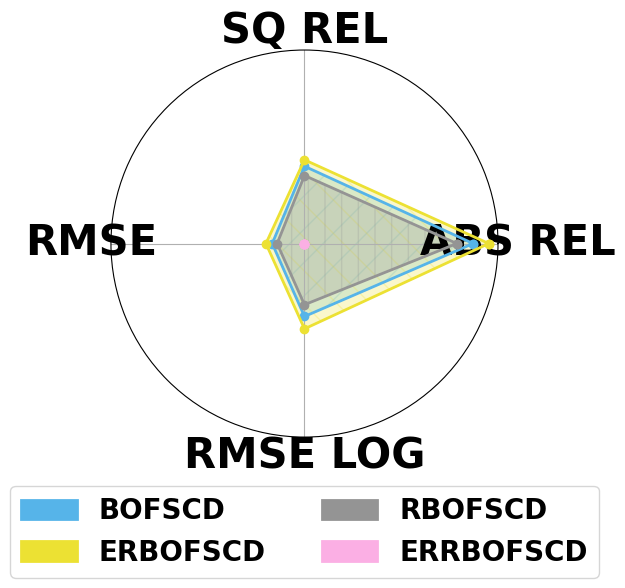

Saved radar chart: kitti_ddad_spto_err.pdf


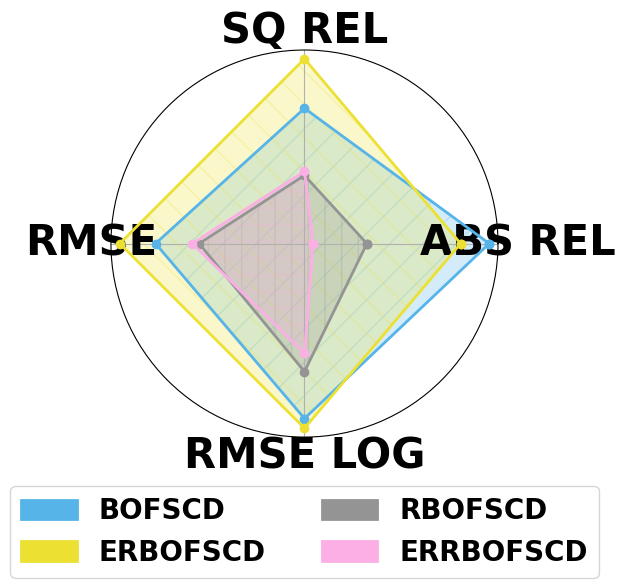

In [6]:
loss_metrics = ['test_abs_rel', 'test_sq_rel', 'test_rmse', 'test_rmse_log']
analysis.generate_radar_charts(df_stability_plasticity_tradeoff, loss_metrics, 'ERROR', target_methods, True, True, colors, hatches)

,source_train_dataset,target_train_dataset,training_method,test_abs_rel,test_sq_rel,test_rmse,test_rmse_log,test_a1,test_a2,test_a3
5,DDAD,KITTI,ERBOFSCD,0.188,3.817,16.714,0.321,0.686,0.868,0.928
0,DDAD,KITTI,BOFSCD,0.191,3.865,16.900,0.325,0.671,0.861,0.925
2,DDAD,KITTI,RBOFSCD,0.194,3.936,17.044,0.329,0.667,0.857,0.923
1,DDAD,KITTI,ERRBOFSCD,0.219,4.452,17.851,0.349,0.644,0.848,0.922
11,KITTI,DDAD,BOFSCD,0.164,2.083,8.532,0.242,0.775,0.922,0.969
16,KITTI,DDAD,ERBOFSCD,0.165,1.976,8.231,0.241,0.767,0.925,0.971
13,KITTI,DDAD,RBOFSCD,0.170,2.229,8.900,0.246,0.762,0.918,0.967
12,KITTI,DDAD,ERRBOFSCD,0.173,2.220,8.843,0.248,0.752,0.917,0.967


,source_train_dataset,target_train_dataset,training_method,test_abs_rel,test_sq_rel,test_rmse,test_rmse_log,test_a1,test_a2,test_a3
5,DDAD,KITTI,ERBOFSCD,0.188,3.817,16.714,0.321,0.318,0.256,0.126
0,DDAD,KITTI,BOFSCD,0.191,3.865,16.900,0.325,0.204,0.173,0.061
2,DDAD,KITTI,RBOFSCD,0.194,3.936,17.044,0.329,0.172,0.117,0.013
1,DDAD,KITTI,ERRBOFSCD,0.219,4.452,17.851,0.349,0.000,0.000,0.000
11,KITTI,DDAD,BOFSCD,0.164,2.083,8.532,0.242,1.000,0.967,0.969
16,KITTI,DDAD,ERBOFSCD,0.165,1.976,8.231,0.241,0.935,1.000,1.000
13,KITTI,DDAD,RBOFSCD,0.170,2.229,8.900,0.246,0.897,0.905,0.917
12,KITTI,DDAD,ERRBOFSCD,0.173,2.220,8.843,0.248,0.824,0.895,0.917


Saved radar chart: ddad_kitti_spto_acc.pdf


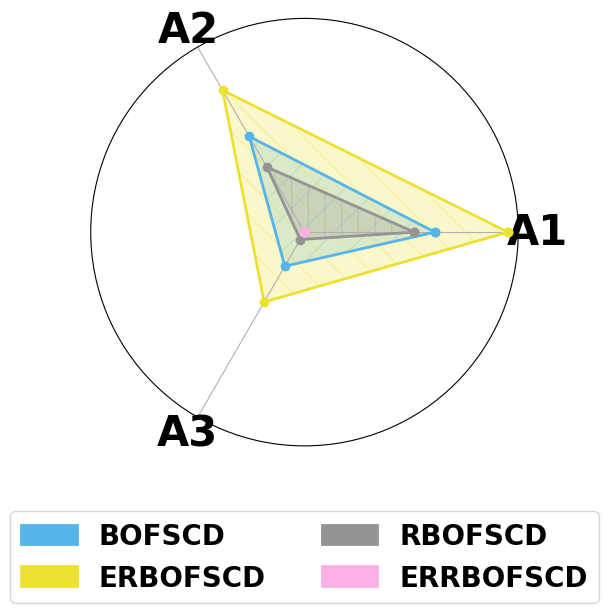

Saved radar chart: kitti_ddad_spto_acc.pdf


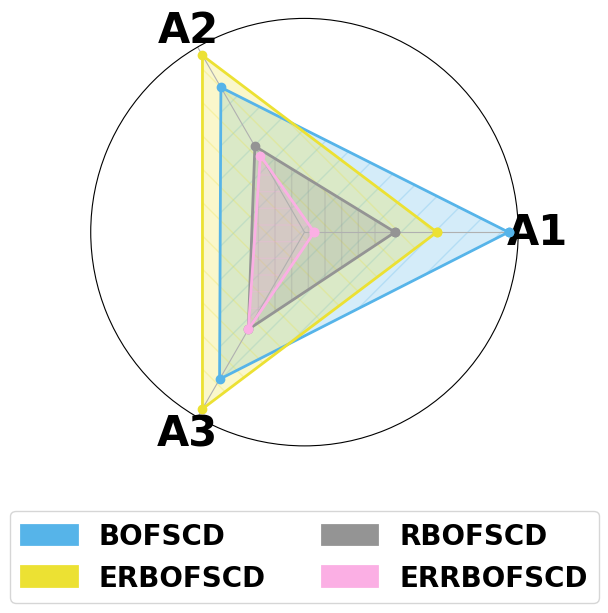

In [7]:
accuracy_metrics = ['test_a1', 'test_a2', 'test_a3']
analysis.generate_radar_charts(df_stability_plasticity_tradeoff, accuracy_metrics, 'ACCURACY', target_methods, True, False, colors, hatches)